   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Missing Values
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Cluster Summary
Cluster
1    354
0     64
2     22
Name: count, dtype: int64

CLUSTER 1
     Fresh   Milk
4    22615   5410
12   31714  12319
14   24653   9465
22   31276   1917
24   22647   9776
..     ...    ...
406  25066   5010
422  26400   1377
427  31012  16687
435  29703  12051
436  39228   1431

[64 rows x 2 co

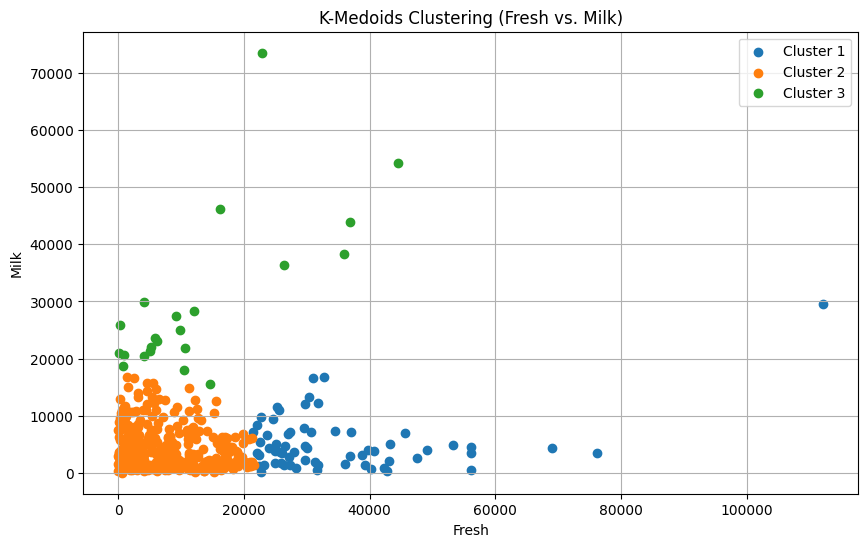

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pyclustering.cluster.kmedoids import kmedoids

df = pd.read_csv(
    "/content/Wholesale customers data.csv",
    sep=","
)

print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

X = df[
    [
        "Fresh", # Changed from "Income"
        "Milk"   # Changed from "MntWines"
    ]
]

data = X.values.tolist()

initial_medoids = [0, 100, 200] # These might need adjustment based on the new column ranges

kmedoids_instance = kmedoids(
    data,
    initial_medoids
)

kmedoids_instance.process()

clusters = kmedoids_instance.get_clusters()

df["Cluster"] = -1

for cluster_id, cluster_points in enumerate(clusters):

    for point in cluster_points:

        df.loc[df.index[point], "Cluster"] = cluster_id

print("\nCluster Summary")
print(df["Cluster"].value_counts())

for i in sorted(df["Cluster"].unique()):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Fresh", # Changed from "Income"
                "Milk"   # Changed from "MntWines"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )

plt.figure(figsize=(10,6))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Fresh"], # Changed from "Income"
        cluster_data["Milk"],   # Changed from "MntWines"
        label=f"Cluster {cluster+1}"
    )

plt.xlabel("Fresh") # Changed from "Income"
plt.ylabel("Milk")   # Changed from "MntWines"

plt.title("K-Medoids Clustering (Fresh vs. Milk)") # Updated title

plt.legend()

plt.grid(True)

plt.show()